# HR Feature Engineering

## Load cleaned data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/processed/HRDataset_v14_cleaned.csv")

In [3]:
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences,SalaryBand,EngagementQuartile,QualityOfHire,Tenure,SalaryRelativeToDept,Promoted
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,0,2019-01-17,0,1,50k-100k,Q3,0.9735,8.490075,1.042574,0
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,6,2016-02-24,0,17,100k-150k,Q4,0.6551,1.215606,1.075953,0
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,0,2012-05-15,0,3,50k-100k,Q1,0.5737,1.223819,1.083422,0
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,0,2019-01-03,0,15,50k-100k,Q4,0.8529,11.980835,1.084023,1
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,0,2016-02-01,0,2,50k-100k,Q4,0.6950,5.158111,0.847740,0


## Engineer basic features

In [4]:
# create age, years since review, and age at hire features
from datetime import datetime


def calculate_age(dob):
    if pd.isna(dob):
        return np.nan
    today = datetime(2019, 12, 31)
    age = (today - dob).days / 365.25
    return age

def calculate_tenure(hire_date, term_date):
    if pd.isna(hire_date):
        return np.nan
    if not pd.isna(term_date):
         if term_date < hire_date:
             return np.nan
         tenure = (term_date - hire_date).days / 365.25
    else:
        current_date = datetime(2019, 12, 31)
        tenure = (current_date - hire_date).days / 365.25
    return tenure

def calculate_years_since_review(last_review_date):
    if pd.isna(last_review_date):
        return np.nan
    current_date = datetime(2019, 12, 31)
    years_since_review = (current_date - last_review_date).days / 365.25
    return years_since_review

def calculate_age_at_hire(dob, hire_date):
    if pd.isna(dob) or pd.isna(hire_date):
        return np.nan
    if hire_date < dob:
        return np.nan
    age_at_hire = (hire_date - dob).days / 365.25
    return age_at_hire

df["DOB"] = pd.to_datetime(df["DOB"], errors="coerce")
df["DateofHire"] = pd.to_datetime(df["DateofHire"], errors="coerce")
df["DateofTermination"] = pd.to_datetime(df["DateofTermination"], errors="coerce")
df["LastPerformanceReview_Date"] = pd.to_datetime(df["LastPerformanceReview_Date"], errors="coerce")
df["Age"] = df["DOB"].apply(calculate_age)
df["Tenure"] = df.apply(lambda row: calculate_tenure(row["DateofHire"], row["DateofTermination"]), axis=1)
df["YearsSinceReview"] = df["LastPerformanceReview_Date"].apply(calculate_years_since_review)
df["AgeAtHire"] = df.apply(lambda row: calculate_age_at_hire(row["DOB"], row["DateofHire"]), axis=1)

df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,Absences,SalaryBand,EngagementQuartile,QualityOfHire,Tenure,SalaryRelativeToDept,Promoted,Age,YearsSinceReview,AgeAtHire
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,1,50k-100k,Q3,0.9735,8.490075,1.042574,0,36.476386,0.952772,27.986311
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,17,100k-150k,Q4,0.6551,1.215606,1.075953,0,44.657084,3.849418,39.901437
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,3,50k-100k,Q1,0.5737,1.223819,1.083422,0,31.279945,7.627652,22.789870
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,15,50k-100k,Q4,0.8529,11.980835,1.084023,1,31.258042,0.991102,19.277207
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,2,50k-100k,Q4,0.6950,5.158111,0.847740,0,30.310746,3.912389,21.837098


In [7]:
df[["Age", "Tenure", "YearsSinceReview", "AgeAtHire"]].describe()

,Age,Tenure,YearsSinceReview,AgeAtHire
count,311.000000,311.000000,311.000000,311.000000
mean,40.896897,5.381972,2.302841,33.994643
std,8.888217,2.394561,2.265881,8.943364
min,27.370294,0.071184,0.837782,19.222450
25%,33.589322,3.867214,0.903491,27.451061
50%,39.249829,5.253936,0.955510,32.147844
75%,46.075291,6.806297,3.782341,39.049966
max,68.993840,13.973990,9.464750,63.739904


## Handle missing values

In [8]:
# list columns with missing values
df.columns[df.isna().any()].tolist()

['DateofTermination', 'ManagerID']

### ManagerID

In [9]:
# locate rows with missing ManagerID
df[df["ManagerID"].isna()]

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,Absences,SalaryBand,EngagementQuartile,QualityOfHire,Tenure,SalaryRelativeToDept,Promoted,Age,YearsSinceReview,AgeAtHire
19,"Becker, Scott",10277,0,0,1,3,5,3,0,53250,...,13,50k-100k,Q2,0.8195,6.480493,0.888188,0,40.736482,0.969199,34.255989
30,"Buccheri, Joseph",10184,0,0,1,1,5,3,0,65288,...,9,50k-100k,Q1,0.7689,5.253936,1.088976,0,36.427105,0.911704,31.173169
44,"Chang, Donovan E",10154,0,0,1,1,5,3,0,60380,...,4,50k-100k,Q2,0.8180,6.480493,1.007113,0,36.353183,0.960986,29.872690
88,"Fancett, Nicole",10136,0,0,0,1,5,3,0,65902,...,7,50k-100k,Q2,0.8225,5.867214,1.099218,0,32.260096,0.980151,26.392882
135,"Hutter, Rosalie",10214,0,3,0,2,5,3,0,64995,...,6,50k-100k,Q3,0.8550,4.572211,1.084089,0,27.649555,0.876112,23.077344
177,"Manchester, Robyn",10077,1,1,0,2,5,3,0,62385,...,4,50k-100k,Q4,0.8900,3.638604,1.040556,0,43.348392,0.941821,39.709788
232,"Rivera, Haley",10011,1,1,0,1,5,4,0,46738,...,16,0-50k,Q3,0.9216,8.090349,0.779570,0,46.965092,0.884326,38.874743
251,"Sewkumar, Nori",10071,0,0,0,3,5,3,0,50923,...,14,50k-100k,Q4,0.8650,6.250513,0.849374,0,44.810404,0.898015,38.559890


In [11]:
# create a manager ID to manager name mapping
manager_mapping = df[["ManagerID", "ManagerName"]].dropna().set_index("ManagerID")["ManagerName"].to_dict()
manager_mapping

{22.0: 'Michael Albert',
 4.0: 'Simon Roup',
 20.0: 'Kissy Sullivan',
 16.0: 'Elijiah Gray',
 39.0: 'Webster Butler',
 11.0: 'Amy Dunn',
 10.0: 'Alex Sweetwater',
 19.0: 'Ketsia Liebig',
 12.0: 'Brannon Miller',
 7.0: 'Peter Monroe',
 14.0: 'David Stanley',
 18.0: 'Kelley Spirea',
 3.0: 'Brandon R. LeBlanc',
 2.0: 'Janet King',
 1.0: 'Brandon R. LeBlanc',
 17.0: 'John Smith',
 5.0: 'Jennifer Zamora',
 21.0: 'Lynn Daneault',
 6.0: 'Eric Dougall',
 15.0: 'Debra Houlihan',
 13.0: 'Brian Champaigne',
 9.0: 'Board of Directors',
 30.0: 'Michael Albert'}

In [13]:
# impute manager ID missing values based on manager name mapping
import numpy as np


df["ManagerID"] = df.apply(lambda row: row["ManagerID"] if not pd.isna(row["ManagerID"]) else next((k for k, v in manager_mapping.items() if v == row["ManagerName"]), np.nan), axis=1)

In [14]:
# locate rows with missing ManagerID
df[df["ManagerID"].isna()]

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,Absences,SalaryBand,EngagementQuartile,QualityOfHire,Tenure,SalaryRelativeToDept,Promoted,Age,YearsSinceReview,AgeAtHire


Looks like missing manager IDs are resolved

### DateofTermination

In [19]:
# see if any Termd = 1 rows have missing termination dates
df[(df["Termd"] == 1) & (df["DateofTermination"].isna())]

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,Absences,SalaryBand,EngagementQuartile,QualityOfHire,Tenure,SalaryRelativeToDept,Promoted,Age,YearsSinceReview,AgeAtHire


Looks like missing dates of termination are valid

## Explore duplicates

In [26]:
# see if employee ID has any duplicates
df["EmpID"].duplicated().any()

np.False_

In [30]:
# see if employee name has any duplicates
df["Employee_Name"].duplicated().any()

np.False_

## Outlier exploration

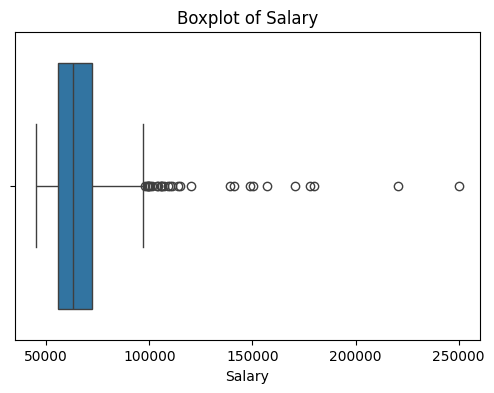

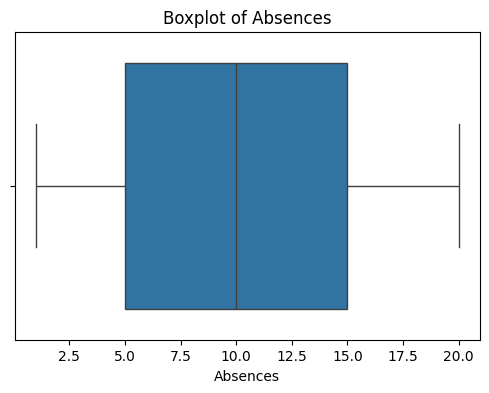

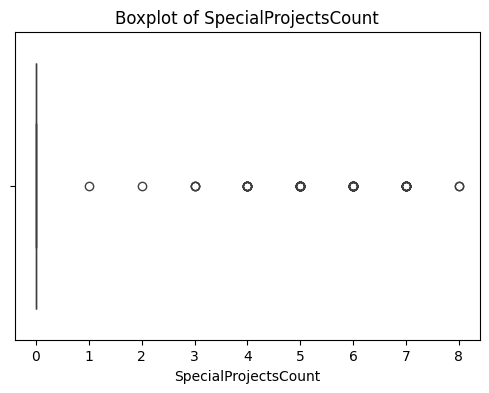

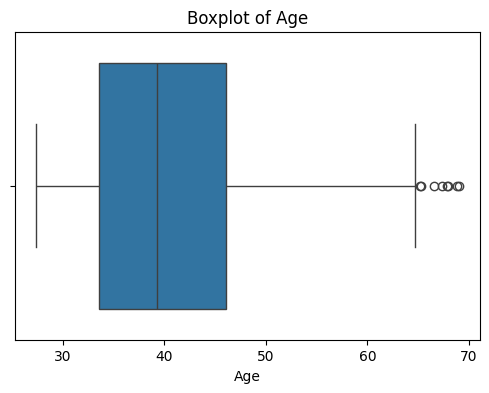

In [35]:
# detect outliers in salary, absences, projects, and age
import matplotlib.pyplot as plt
import seaborn as sns


for col in ["Salary", "Absences", "SpecialProjectsCount", "Age"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

All values appear sensible

## Engineer complex features

### time-based

In [36]:
# engineer tenure_days, tenure_years, months_since_review, and generation_bucket
df["Tenure_Days"] = (df["DateofTermination"].fillna(datetime(2019, 12, 31)) - df["DateofHire"]).dt.days
df["Tenure_Years"] = df["Tenure_Days"] / 365.25
df["MonthsSinceReview"] = df["YearsSinceReview"] * 12

generations = {
    "Silent Generation": (datetime(1928, 1, 1), datetime(1945, 12, 31)),
    "Baby Boomers": (datetime(1946, 1, 1), datetime(1964, 12, 31)),
    "Generation X": (datetime(1965, 1, 1), datetime(1980, 12, 31)),
    "Millennials": (datetime(1981, 1, 1), datetime(1996, 12, 31)),
    "Generation Z": (datetime(1997, 1, 1), datetime(2012, 12, 31)),
}

def assign_generation(dob):
    if pd.isna(dob):
        return np.nan
    for generation, (start, end) in generations.items():
        if start <= dob <= end:
            return generation
    return "Unknown"

df["Generation"] = df["DOB"].apply(assign_generation)

In [37]:
df.Generation.value_counts()

Generation
Millennials     155
Generation X    134
Baby Boomers     22
Name: count, dtype: int64

### behavioral

In [38]:
# engineer absent_rate, lateness_flag, and high_engagement_flag
df["Absent_Rate"] = df["Absences"] / df["Tenure_Years"]
df["Lateness_Flag"] = df["Absent_Rate"] > 0.1
df["High_Engagement_Flag"] = (df["SpecialProjectsCount"] > 2) & (df["YearsSinceReview"] < 1)

## Standardize and prepare for modeling

In [40]:
# standardize column names (lowercase with underscores)
# first lowercase all column names
df.columns = df.columns.str.lower()
# then replace spaces with underscores
df.columns = df.columns.str.replace(" ", "_")

df.columns

Index(['employee_name', 'empid', 'marriedid', 'maritalstatusid', 'genderid',
       'empstatusid', 'deptid', 'perfscoreid', 'fromdiversityjobfairid',
       'salary', 'termd', 'positionid', 'position', 'state', 'zip', 'dob',
       'sex', 'maritaldesc', 'citizendesc', 'hispaniclatino', 'racedesc',
       'dateofhire', 'dateoftermination', 'termreason', 'employmentstatus',
       'department', 'managername', 'managerid', 'recruitmentsource',
       'performancescore', 'engagementsurvey', 'empsatisfaction',
       'specialprojectscount', 'lastperformancereview_date', 'dayslatelast30',
       'absences', 'salaryband', 'engagementquartile', 'qualityofhire',
       'tenure', 'salaryrelativetodept', 'promoted', 'age', 'yearssincereview',
       'ageathire', 'tenure_days', 'tenure_years', 'monthssincereview',
       'generation', 'absent_rate', 'lateness_flag', 'high_engagement_flag'],
      dtype='object')

In [43]:
# add underscores between words in column names
df.rename(columns={
    "empid": "employee_id",
    "marriedid": "married_id",
    "maritalstatusid": "marital_status_id",
    "genderid": "gender_id",
    "empstatusid": "emp_status_id",
    "deptid": "dept_id",
    "perfscoreid": "perf_score_id",
    "fromdiversityjobfairid": "from_diversity_job_fair_id",
    "positionid": "position_id",
    "maritaldesc": "marital_desc",
    "citizendesc": "citizen_desc",
    "hispaniclatino": "hispanic_latino",
    "racedesc": "race_desc",
    "dateofhire": "date_of_hire",
    "dateoftermination": "date_of_termination",
    "termreason": "term_reason",
    "employmentstatus": "employment_status",
    "managername": "manager_name",
    "managerid": "manager_id",
    "recruitmentsource": "recruitment_source",
    "performancescore": "performance_score",
    "performancescoredesc": "performance_score_desc",
    "engagementsurvey": "engagement_survey",
    "empsatisfaction": "emp_satisfaction",
    "specialprojectscount": "special_projects_count",
    "lastperformancereview_date": "last_performance_review_date",
    "dayslatelast30": "days_late_last_30",
    "salaryband" : "salary_band",
    "engagementquartile": "engagement_quartile",
    "qualityofhire": "quality_of_hire",
    "salaryrelativetodept": "salary_relative_to_dept",
    "yearssincereview" : "years_since_review",
    "ageathire": "age_at_hire",
    "monthssincereview": "months_since_review"
}, inplace=True)

In [44]:
df.columns

Index(['employee_name', 'employee_id', 'married_id', 'marital_status_id',
       'gender_id', 'emp_status_id', 'dept_id', 'perf_score_id',
       'from_diversity_job_fair_id', 'salary', 'termd', 'position_id',
       'position', 'state', 'zip', 'dob', 'sex', 'marital_desc',
       'citizen_desc', 'hispanic_latino', 'race_desc', 'date_of_hire',
       'date_of_termination', 'term_reason', 'employment_status', 'department',
       'manager_name', 'manager_id', 'recruitment_source', 'performance_score',
       'engagement_survey', 'emp_satisfaction', 'special_projects_count',
       'last_performance_review_date', 'days_late_last_30', 'absences',
       'salary_band', 'engagement_quartile', 'quality_of_hire', 'tenure',
       'salary_relative_to_dept', 'promoted', 'age', 'years_since_review',
       'age_at_hire', 'tenure_days', 'tenure_years', 'months_since_review',
       'generation', 'absent_rate', 'lateness_flag', 'high_engagement_flag'],
      dtype='object')

## Export engineered dataset

In [46]:
df.to_csv("../data/processed/HRDataset_v14_engineered.csv", index=False)